# Mérési notebook
---
# **3. mérési fázis**. A	Modellek tesztelése teljes tanítással.

#### **Cél**: Modellek tesztelése saját adathalmazon, majd saját modell ötletek tesztelése
#### **Diplomamunka címe**: Fotográfiai témafelismerés neurális hálózatokkal nagy adathalmazon.
#### **Készítette**: Sándor Balázs - AZA6NL

## 7. modell **NASNet** modell teljes tanítással történő tesztelése

#### A NASNet modell tesztelése 1k, 5k, 10k, 25k tanítás után a saját SBphotothemes180k adathalmaz Test részhalmazán. (teszt elemszám: 18k).

---

✅ NASNet-A-Large – 3. vizsgálati fázis (Few-shot fine-tune)

🔷 BLOKK 1 – Telepítés, importálás, GPU ellenőrzés

In [ ]:
!pip install -q timm torchvision scikit-learn matplotlib tqdm

import os
os.environ["PYTORCH_CUDA_ALLOC_CONF"] = "expandable_segments:True"

import torch
import torch.nn as nn
import torch.nn.functional as F
from torchvision import datasets, transforms, models
from torch.utils.data import DataLoader, Subset
import numpy as np
import matplotlib.pyplot as plt
from tqdm import tqdm
import os, time, random
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score,
    f1_score, top_k_accuracy_score, confusion_matrix
)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("🖥️ GPU elérhetőség:", device)


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 363.4/363.4 MB 4.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 13.8/13.8 MB 97.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 24.6/24.6 MB 95.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 883.7/883.7 kB 46.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 664.8/664.8 MB 1.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 211.5/211.5 MB 11.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 56.3/56.3 MB 35.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 127.9/127.9 MB 19.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 207.5/207.5 MB 3.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 21.1/21.1 MB 94.6 MB/s eta 0:00:00
🖥️ GPU elérhetőség: cuda


🔷 BLOKK 2 – Google Drive csatolás, adatbázis kicsomagolása

In [ ]:
from google.colab import drive
import zipfile

drive.mount('/content/drive')
diploma_path = "/content/drive/MyDrive/diplomamunka"
zip_path = os.path.join(diploma_path, "imagenet_splitted_db.zip")
extract_path = "/content/imagenet_splitted_db"

if not os.path.exists(extract_path):
    with zipfile.ZipFile(zip_path, 'r') as zip_ref:
        zip_ref.extractall(extract_path)

print("✅ Adatok kibontva:", extract_path)


Mounted at /content/drive
✅ Adatok kibontva: /content/imagenet_splitted_db


Mappa pontosítás

In [ ]:
extract_path = "/content/imagenet_splitted_db/imagenet_splitted_db"

🔷 BLOKK 3 – Adatok betöltése, szétválogatás részhalmazokra

In [ ]:
from collections import defaultdict

transform = transforms.Compose([
    transforms.Resize(331),
    transforms.CenterCrop(331),
    transforms.ToTensor(),
    transforms.Normalize([0.5, 0.5, 0.5], [0.5, 0.5, 0.5])
])

train_dataset_full = datasets.ImageFolder(os.path.join(extract_path, "train"), transform=transform)
val_dataset         = datasets.ImageFolder(os.path.join(extract_path, "val"), transform=transform)
test_dataset        = datasets.ImageFolder(os.path.join(extract_path, "test"), transform=transform)

# Stratifikált mintavétel
def stratified_subset(dataset, total_images):
    class_indices = defaultdict(list)
    for idx, (_, label) in enumerate(dataset.samples):
        class_indices[label].append(idx)

    per_class = total_images // len(class_indices)
    selected_indices = []

    for cls, indices in class_indices.items():
        chosen = random.sample(indices, min(per_class, len(indices)))
        selected_indices.extend(chosen)

    print(f"📦 Kiválasztott képek: {len(selected_indices)}")
    return Subset(dataset, selected_indices)

subset_sizes = [1000, 5000, 10000, 25000]
subsets = {f"{size}": stratified_subset(train_dataset_full, size) for size in subset_sizes}

val_loader = DataLoader(val_dataset, batch_size=64, shuffle=False, num_workers=2)
test_loader = DataLoader(test_dataset, batch_size=64, shuffle=False, num_workers=2)

class_names = train_dataset_full.classes
num_classes = len(class_names)


📦 Kiválasztott képek: 912
📦 Kiválasztott képek: 4902
📦 Kiválasztott képek: 9918
📦 Kiválasztott képek: 24966


🔷 BLOKK 4 – NASNet-A-Large modell betöltése és testreszabása

In [ ]:
import timm

def get_nasnet_model():
    model = timm.create_model("nasnetalarge", pretrained=True, num_classes=num_classes)
    return model.to(device)


🔷 BLOKK 5 – Általános tanítófüggvény NASNet modellekhez

In [ ]:
def train_on_subset(train_dataset, subset_name, num_epochs=10):
    print(f"\n🚀 Tanítás: {subset_name} képes halmaz (NASNet-A-Large)")

    # 🔧 Memóriabarát betöltés kis batch-ekkel
    train_loader = DataLoader(train_dataset, batch_size=4, shuffle=True, num_workers=2, pin_memory=True)
    model = get_nasnet_model()
    optimizer = torch.optim.Adam(model.parameters(), lr=1e-4)
    criterion = nn.CrossEntropyLoss()

    train_loss_hist, val_loss_hist = [], []
    train_acc_hist, val_acc_hist = [], []

    torch.cuda.empty_cache()  # indulás előtt is ürítünk

    for epoch in range(num_epochs):
        model.train()
        running_loss, correct, total = 0.0, 0, 0

        for inputs, labels in tqdm(train_loader, desc=f"Epoch {epoch+1}/{num_epochs} - train"):
            inputs, labels = inputs.to(device, non_blocking=True), labels.to(device, non_blocking=True)
            optimizer.zero_grad()

            try:
                outputs = model(inputs)
                loss = criterion(outputs, labels)
                loss.backward()
                optimizer.step()
            except RuntimeError as e:
                if "out of memory" in str(e):
                    print("⚠️ CUDA out of memory – skipping batch")
                    torch.cuda.empty_cache()
                    continue
                else:
                    raise e

            running_loss += loss.item() * inputs.size(0)
            _, preds = torch.max(outputs, 1)
            correct += (preds == labels).sum().item()
            total += labels.size(0)

            torch.cuda.empty_cache()  # minden batch után, NASNet-hez segít

        train_loss = running_loss / total
        train_acc = correct / total
        train_loss_hist.append(train_loss)
        train_acc_hist.append(train_acc)

        # --- Validáció ---
        model.eval()
        val_loss, correct, total = 0.0, 0, 0

        with torch.no_grad():
            for inputs, labels in tqdm(val_loader, desc=f"Epoch {epoch+1}/{num_epochs} - val"):
                inputs, labels = inputs.to(device, non_blocking=True), labels.to(device, non_blocking=True)

                try:
                    outputs = model(inputs)
                    loss = criterion(outputs, labels)
                except RuntimeError as e:
                    if "out of memory" in str(e):
                        print("⚠️ CUDA out of memory – skipping batch")
                        torch.cuda.empty_cache()
                        continue
                    else:
                        raise e

                val_loss += loss.item() * inputs.size(0)
                _, preds = torch.max(outputs, 1)
                correct += (preds == labels).sum().item()
                total += labels.size(0)

        val_loss /= total
        val_acc = correct / total
        val_loss_hist.append(val_loss)
        val_acc_hist.append(val_acc)

        print(f"📊 Epoch {epoch+1}: Train loss={train_loss:.4f}, acc={train_acc:.4f} | Val loss={val_loss:.4f}, acc={val_acc:.4f}")

    return model, train_loss_hist, val_loss_hist, train_acc_hist, val_acc_hist


🔷 BLOKK 6 – NASNet @ 1k képes részhalmaz

🚀 Tanítás + tanulási görbék


🚀 Tanítás: 1k képes halmaz (NASNet-A-Large)


/usr/local/lib/python3.11/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


model.safetensors:   0%|          | 0.00/356M [00:00<?, ?B/s]

Epoch 1/5 - val: 100%|██████████| 282/282 [01:21<00:00,  3.47it/s]


📊 Epoch 1: Train loss=4.4943, acc=0.0789 | Val loss=3.2968, acc=0.2334


...

📊 Epoch 3: Train loss=1.2119, acc=0.6985 | Val loss=3.3285, acc=0.3500


Epoch 4/5 - val: 100%|██████████| 282/282 [01:21<00:00,  3.47it/s]


📊 Epoch 4: Train loss=0.4945, acc=0.8761 | Val loss=4.1111, acc=0.3110


Epoch 5/5 - val: 100%|██████████| 282/282 [01:21<00:00,  3.47it/s]


📊 Epoch 5: Train loss=0.2662, acc=0.9441 | Val loss=4.0139, acc=0.3285


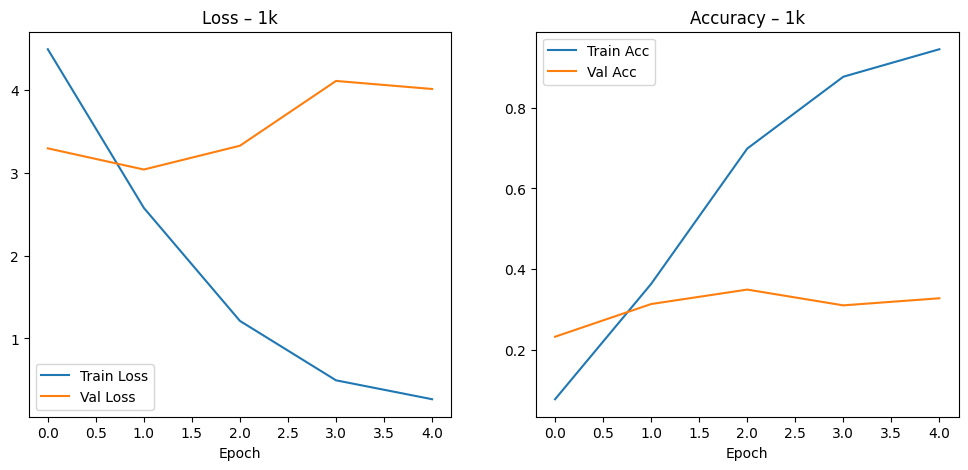

In [ ]:
model_1k, train_loss_1k, val_loss_1k, train_acc_1k, val_acc_1k = train_on_subset(subsets["1000"], "1k", num_epochs=5)

# Tanulási görbék – 1k
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.plot(train_loss_1k, label="Train Loss")
plt.plot(val_loss_1k, label="Val Loss")
plt.title("Loss – 1k")
plt.xlabel("Epoch")
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(train_acc_1k, label="Train Acc")
plt.plot(val_acc_1k, label="Val Acc")
plt.title("Accuracy – 1k")
plt.xlabel("Epoch")
plt.legend()
plt.show()


🧪 Tesztelés – Metrikák (1k modellen)

In [ ]:
model_1k.eval()
all_preds, all_probs, all_labels = [], [], []
start = time.perf_counter()

with torch.no_grad():
    for inputs, labels in test_loader:
        inputs, labels = inputs.to(device), labels.to(device)
        outputs = model_1k(inputs)
        probs = F.softmax(outputs, dim=1)
        preds = torch.argmax(probs, dim=1)

        all_preds.extend(preds.cpu().numpy())
        all_probs.extend(probs.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())

inference_time = time.perf_counter() - start
y_true = np.array(all_labels)
y_pred = np.array(all_preds)
y_probs = np.array(all_probs)

print("\n🔍 Metrikák – NASNet trained on 1k:")
print(f"✅ Top-1 Accuracy:  {accuracy_score(y_true, y_pred):.4f}")
print(f"✅ Top-5 Accuracy:  {top_k_accuracy_score(y_true, y_probs, k=5):.4f}")
print(f"🎯 Precision:       {precision_score(y_true, y_pred, average='macro', zero_division=0):.4f}")
print(f"🎯 Recall:          {recall_score(y_true, y_pred, average='macro', zero_division=0):.4f}")
print(f"🎯 F1-score:        {f1_score(y_true, y_pred, average='macro', zero_division=0):.4f}")
print(f"⏱️ Inference time:  {inference_time:.2f} sec")



🔍 Metrikák – NASNet trained on 1k:
✅ Top-1 Accuracy:  0.3324
✅ Top-5 Accuracy:  0.6131
🎯 Precision:       0.3456
🎯 Recall:          0.3690
🎯 F1-score:        0.3261
⏱️ Inference time:  81.04 sec


🔷 BLOKK 7 – NASNet @ 5k képes részhalmaz

🚀 Tanítás + tanulási görbék


🚀 Tanítás: 5k képes halmaz (NASNet-A-Large)


Epoch 1/5 - val: 100%|██████████| 282/282 [01:21<00:00,  3.47it/s]


📊 Epoch 1: Train loss=3.1256, acc=0.2678 | Val loss=3.1782, acc=0.3521


Epoch 2/5 - val: 100%|██████████| 282/282 [01:21<00:00,  3.47it/s]


📊 Epoch 2: Train loss=1.7259, acc=0.5279 | Val loss=2.9296, acc=0.4284


...

📊 Epoch 3: Train loss=0.9826, acc=0.7189 | Val loss=3.2216, acc=0.4299


Epoch 4/5 - val: 100%|██████████| 282/282 [01:21<00:00,  3.47it/s]


📊 Epoch 4: Train loss=0.5718, acc=0.8427 | Val loss=3.8691, acc=0.3981


Epoch 5/5 - val: 100%|██████████| 282/282 [01:21<00:00,  3.47it/s]


📊 Epoch 5: Train loss=0.4060, acc=0.8800 | Val loss=4.6202, acc=0.4074


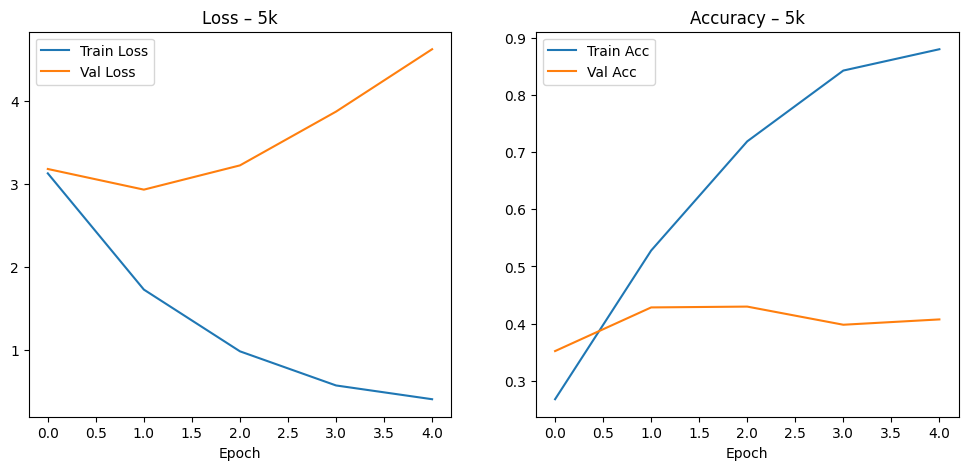

In [ ]:
model_5k, train_loss_5k, val_loss_5k, train_acc_5k, val_acc_5k = train_on_subset(subsets["5000"], "5k", num_epochs=5)

# Tanulási görbék – 5k
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.plot(train_loss_5k, label="Train Loss")
plt.plot(val_loss_5k, label="Val Loss")
plt.title("Loss – 5k")
plt.xlabel("Epoch")
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(train_acc_5k, label="Train Acc")
plt.plot(val_acc_5k, label="Val Acc")
plt.title("Accuracy – 5k")
plt.xlabel("Epoch")
plt.legend()
plt.show()


🧪 Tesztelés – Metrikák (5k modellen)

In [ ]:
model_5k.eval()
all_preds, all_probs, all_labels = [], [], []
start = time.perf_counter()

with torch.no_grad():
    for inputs, labels in test_loader:
        inputs, labels = inputs.to(device), labels.to(device)
        outputs = model_5k(inputs)
        probs = F.softmax(outputs, dim=1)
        preds = torch.argmax(probs, dim=1)

        all_preds.extend(preds.cpu().numpy())
        all_probs.extend(probs.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())

inference_time = time.perf_counter() - start
y_true = np.array(all_labels)
y_pred = np.array(all_preds)
y_probs = np.array(all_probs)

print("\n🔍 Metrikák – NASNet trained on 5k:")
print(f"✅ Top-1 Accuracy:  {accuracy_score(y_true, y_pred):.4f}")
print(f"✅ Top-5 Accuracy:  {top_k_accuracy_score(y_true, y_probs, k=5):.4f}")
print(f"🎯 Precision:       {precision_score(y_true, y_pred, average='macro', zero_division=0):.4f}")
print(f"🎯 Recall:          {recall_score(y_true, y_pred, average='macro', zero_division=0):.4f}")
print(f"🎯 F1-score:        {f1_score(y_true, y_pred, average='macro', zero_division=0):.4f}")
print(f"⏱️ Inference time:  {inference_time:.2f} sec")



🔍 Metrikák – NASNet trained on 5k:
✅ Top-1 Accuracy:  0.4062
✅ Top-5 Accuracy:  0.6912
🎯 Precision:       0.4096
🎯 Recall:          0.4284
🎯 F1-score:        0.3844
⏱️ Inference time:  81.54 sec


🔷 BLOKK 8 – NASNet @ 10k képes részhalmaz

🚀 Tanítás + tanulási görbék


🚀 Tanítás: 10k képes halmaz (NASNet-A-Large)


Epoch 1/3 - val: 100%|██████████| 282/282 [01:21<00:00,  3.46it/s]


📊 Epoch 1: Train loss=2.7872, acc=0.3202 | Val loss=3.1433, acc=0.4165


Epoch 2/3 - val: 100%|██████████| 282/282 [01:21<00:00,  3.46it/s]


📊 Epoch 2: Train loss=1.6655, acc=0.5420 | Val loss=2.9456, acc=0.4947


Epoch 3/3 - val: 100%|██████████| 282/282 [01:21<00:00,  3.46it/s]


📊 Epoch 3: Train loss=1.0698, acc=0.6930 | Val loss=3.4763, acc=0.4495


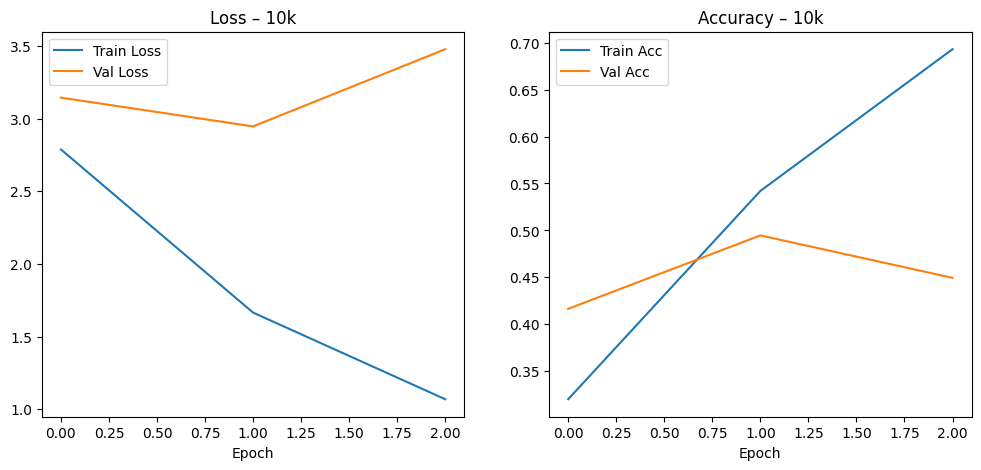

In [ ]:
model_10k, train_loss_10k, val_loss_10k, train_acc_10k, val_acc_10k = train_on_subset(subsets["10000"], "10k", num_epochs=3)

# Tanulási görbék – 10k
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.plot(train_loss_10k, label="Train Loss")
plt.plot(val_loss_10k, label="Val Loss")
plt.title("Loss – 10k")
plt.xlabel("Epoch")
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(train_acc_10k, label="Train Acc")
plt.plot(val_acc_10k, label="Val Acc")
plt.title("Accuracy – 10k")
plt.xlabel("Epoch")
plt.legend()
plt.show()


🧪 Tesztelés – Metrikák (10k modellen)

In [ ]:
model_10k.eval()
all_preds, all_probs, all_labels = [], [], []
start = time.perf_counter()

with torch.no_grad():
    for inputs, labels in test_loader:
        inputs, labels = inputs.to(device), labels.to(device)
        outputs = model_10k(inputs)
        probs = F.softmax(outputs, dim=1)
        preds = torch.argmax(probs, dim=1)

        all_preds.extend(preds.cpu().numpy())
        all_probs.extend(probs.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())

inference_time = time.perf_counter() - start
y_true = np.array(all_labels)
y_pred = np.array(all_preds)
y_probs = np.array(all_probs)

print("\n🔍 Metrikák – NASNet trained on 10k:")
print(f"✅ Top-1 Accuracy:  {accuracy_score(y_true, y_pred):.4f}")
print(f"✅ Top-5 Accuracy:  {top_k_accuracy_score(y_true, y_probs, k=5):.4f}")
print(f"🎯 Precision:       {precision_score(y_true, y_pred, average='macro', zero_division=0):.4f}")
print(f"🎯 Recall:          {recall_score(y_true, y_pred, average='macro', zero_division=0):.4f}")
print(f"🎯 F1-score:        {f1_score(y_true, y_pred, average='macro', zero_division=0):.4f}")
print(f"⏱️ Inference time:  {inference_time:.2f} sec")



🔍 Metrikák – NASNet trained on 10k:
✅ Top-1 Accuracy:  0.4438
✅ Top-5 Accuracy:  0.7665
🎯 Precision:       0.4252
🎯 Recall:          0.4736
🎯 F1-score:        0.4133
⏱️ Inference time:  81.46 sec


🔷 BLOKK 9 – NASNet @ 25k képes részhalmaz

🚀 Tanítás + tanulási görbék


🚀 Tanítás: 25k képes halmaz (NASNet-A-Large)


Epoch 1/2 - val: 100%|██████████| 282/282 [01:21<00:00,  3.46it/s]


📊 Epoch 1: Train loss=2.4012, acc=0.3956 | Val loss=2.6687, acc=0.4672


Epoch 2/2 - val: 100%|██████████| 282/282 [01:21<00:00,  3.46it/s]


📊 Epoch 2: Train loss=1.5766, acc=0.5719 | Val loss=2.7290, acc=0.4751


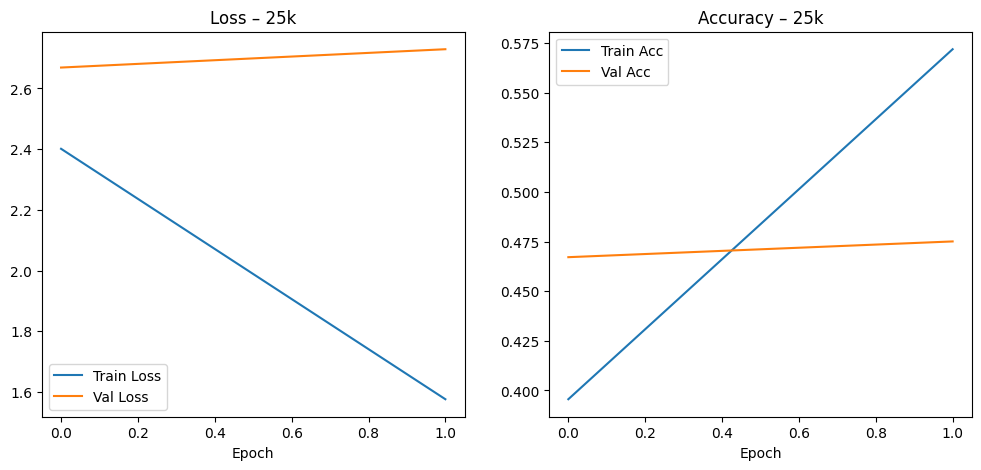

In [ ]:
model_25k, train_loss_25k, val_loss_25k, train_acc_25k, val_acc_25k = train_on_subset(subsets["25000"], "25k", num_epochs=2)

# Tanulási görbék – 25k
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.plot(train_loss_25k, label="Train Loss")
plt.plot(val_loss_25k, label="Val Loss")
plt.title("Loss – 25k")
plt.xlabel("Epoch")
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(train_acc_25k, label="Train Acc")
plt.plot(val_acc_25k, label="Val Acc")
plt.title("Accuracy – 25k")
plt.xlabel("Epoch")
plt.legend()
plt.show()


🧪 Tesztelés – Metrikák (25k modellen)

In [ ]:
model_25k.eval()
all_preds, all_probs, all_labels = [], [], []
start = time.perf_counter()

with torch.no_grad():
    for inputs, labels in test_loader:
        inputs, labels = inputs.to(device), labels.to(device)
        outputs = model_25k(inputs)
        probs = F.softmax(outputs, dim=1)
        preds = torch.argmax(probs, dim=1)

        all_preds.extend(preds.cpu().numpy())
        all_probs.extend(probs.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())

inference_time = time.perf_counter() - start
y_true = np.array(all_labels)
y_pred = np.array(all_preds)
y_probs = np.array(all_probs)

print("\n🔍 Metrikák – NASNet trained on 25k:")
print(f"✅ Top-1 Accuracy:  {accuracy_score(y_true, y_pred):.4f}")
print(f"✅ Top-5 Accuracy:  {top_k_accuracy_score(y_true, y_probs, k=5):.4f}")
print(f"🎯 Precision:       {precision_score(y_true, y_pred, average='macro', zero_division=0):.4f}")
print(f"🎯 Recall:          {recall_score(y_true, y_pred, average='macro', zero_division=0):.4f}")
print(f"🎯 F1-score:        {f1_score(y_true, y_pred, average='macro', zero_division=0):.4f}")
print(f"⏱️ Inference time:  {inference_time:.2f} sec")



🔍 Metrikák – NASNet trained on 25k:
✅ Top-1 Accuracy:  0.4750
✅ Top-5 Accuracy:  0.8059
🎯 Precision:       0.4812
🎯 Recall:          0.5289
🎯 F1-score:        0.4688
⏱️ Inference time:  81.43 sec


🔷 BLOKK 10 – 📊 Összevont tanulási görbék (Train / Val – Acc és Loss)

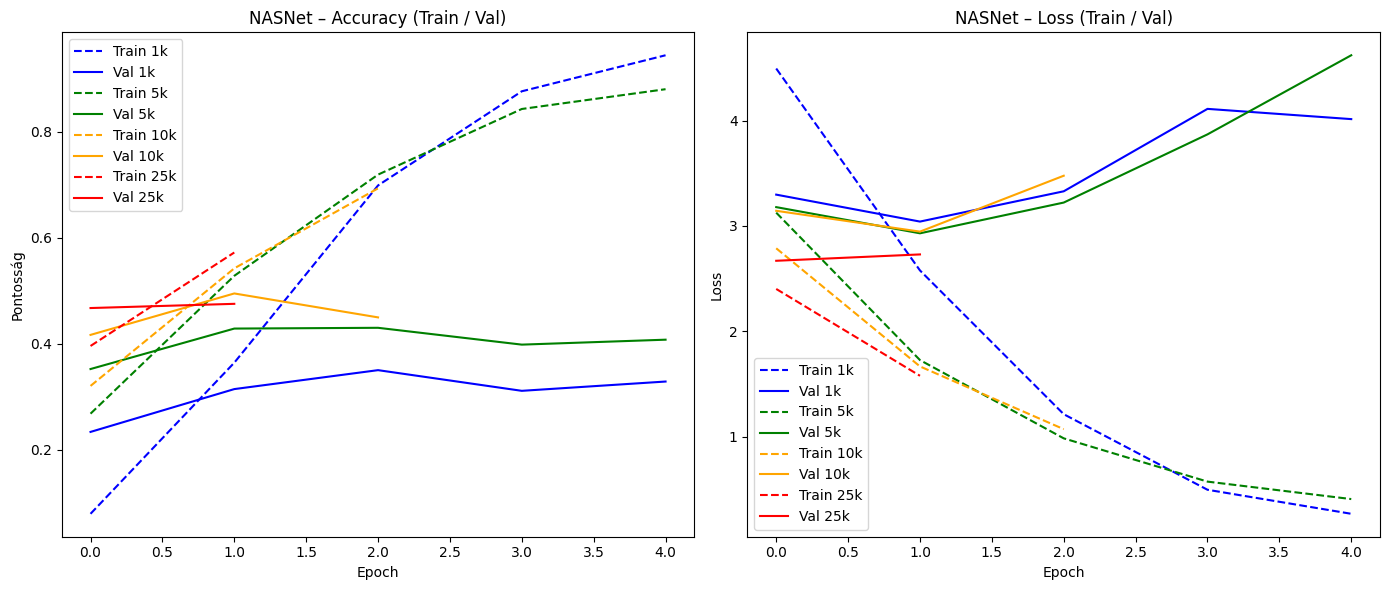

In [ ]:
plt.figure(figsize=(14, 6))

# --- Accuracy ---
plt.subplot(1, 2, 1)
plt.plot(train_acc_1k, label="Train 1k", linestyle='--', color='blue')
plt.plot(val_acc_1k, label="Val 1k", color='blue')
plt.plot(train_acc_5k, label="Train 5k", linestyle='--', color='green')
plt.plot(val_acc_5k, label="Val 5k", color='green')
plt.plot(train_acc_10k, label="Train 10k", linestyle='--', color='orange')
plt.plot(val_acc_10k, label="Val 10k", color='orange')
plt.plot(train_acc_25k, label="Train 25k", linestyle='--', color='red')
plt.plot(val_acc_25k, label="Val 25k", color='red')
plt.title("NASNet – Accuracy (Train / Val)")
plt.xlabel("Epoch")
plt.ylabel("Pontosság")
plt.legend()

# --- Loss ---
plt.subplot(1, 2, 2)
plt.plot(train_loss_1k, label="Train 1k", linestyle='--', color='blue')
plt.plot(val_loss_1k, label="Val 1k", color='blue')
plt.plot(train_loss_5k, label="Train 5k", linestyle='--', color='green')
plt.plot(val_loss_5k, label="Val 5k", color='green')
plt.plot(train_loss_10k, label="Train 10k", linestyle='--', color='orange')
plt.plot(val_loss_10k, label="Val 10k", color='orange')
plt.plot(train_loss_25k, label="Train 25k", linestyle='--', color='red')
plt.plot(val_loss_25k, label="Val 25k", color='red')
plt.title("NASNet – Loss (Train / Val)")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()

plt.tight_layout()
plt.show()


🔷 BLOKK 11 – 🟦 2×2 Confusion Matrix Montázs (Mini)

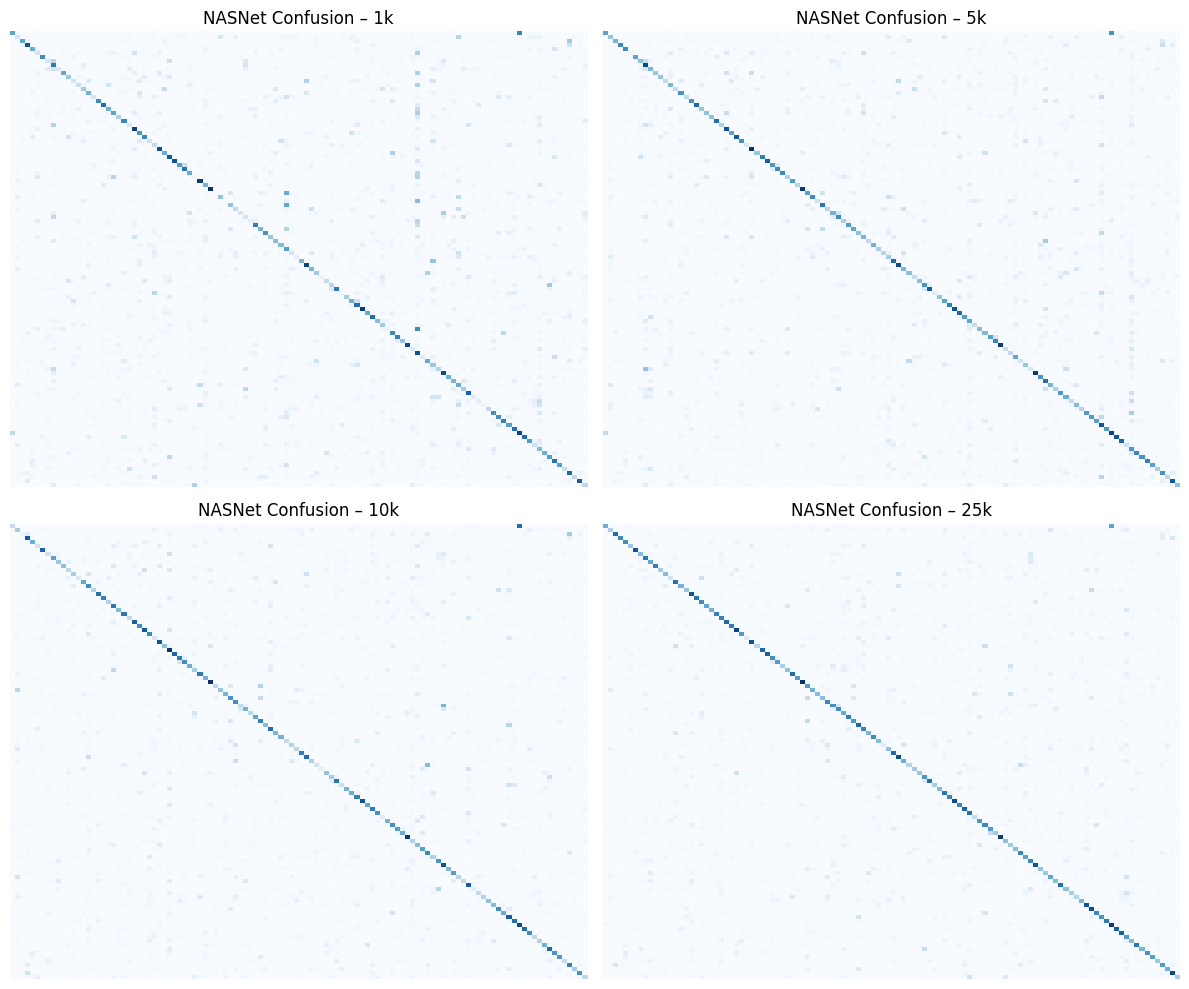

In [ ]:
import seaborn as sns

def plot_mini_confmat(model, title):
    model.eval()
    preds, labels = [], []
    with torch.no_grad():
        for x, y in test_loader:
            x, y = x.to(device), y.to(device)
            out = model(x)
            p = torch.argmax(out, 1)
            preds.extend(p.cpu().numpy())
            labels.extend(y.cpu().numpy())

    cm = confusion_matrix(labels, preds)
    cm_norm = cm.astype("float") / cm.sum(axis=1, keepdims=True)
    cm_norm = np.nan_to_num(cm_norm)

    sns.heatmap(cm_norm, cbar=False, xticklabels=False, yticklabels=False, cmap="Blues")

plt.figure(figsize=(12, 10))
for i, (model, title) in enumerate(zip(
    [model_1k, model_5k, model_10k, model_25k],
    ["1k", "5k", "10k", "25k"]
)):
    plt.subplot(2, 2, i+1)
    plot_mini_confmat(model, title)
    plt.title(f"NASNet Confusion – {title}")

plt.tight_layout()
plt.show()
